# CIDM Lab 2


**Course:** P170M109 Computational Intelligence and Decision Making
**Author:** Rokas Marcinkevi2ius
**Date:** _2025-10-20_

- **Part 1 – Regression using ANN** (reuses Lab 1 dataset)
- **Part 2 – Image Classification** (from scratch + transfer learning)
- **Part 3 – Object Detection & Segmentation** (YOLOv8; segmentation optional)


In [27]:
import sys, platform, numpy as np, pandas as pd, matplotlib, sklearn
print('Python:', sys.version.split()[0])
print('OS:', platform.system(), platform.release())
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('sklearn:', sklearn.__version__)
print('matplotlib:', matplotlib.__version__)


Python: 3.13.2
OS: Darwin 25.0.0
numpy: 2.2.6
pandas: 2.3.2
sklearn: 1.7.2
matplotlib: 3.10.6


## Part 1 — Load Lab 1 Dataset

In [28]:
# P1. Data analysis and preprocessing
# 1) Load data (robust file search)

# Robust read with CSV sniffer and fallbacks (handles stray commas/quotes)
import csv
from pandas.errors import ParserError


def read_csv_robust(path: Path) -> pd.DataFrame:
    # 1) Try to sniff delimiter/quote using csv.Sniffer on a small sample
    try:
        with open(path, 'r', encoding='utf-8', errors='replace') as f:
            sample = f.read(131072)
        dialect = csv.Sniffer().sniff(sample, delimiters=",;\t|")
        delim = dialect.delimiter
        qchar = dialect.quotechar if getattr(dialect, 'quotechar', '"') else '"'
    except Exception:
        delim, qchar = None, '"'  # let pandas infer sep when None

    # 2) Try utf-8 first, engine='python' for better malformed line handling
    try:
        return pd.read_csv(
            path,
            sep=delim,  # None => infer
            encoding='utf-8',
            engine='python',
            quotechar=qchar,
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',  # skip malformed rows instead of failing
        )
    except UnicodeDecodeError:
        # 3) Fallback encoding (Windows-1252) with same tolerant settings
        return pd.read_csv(
            path,
            sep=delim,
            encoding='cp1252',
            engine='python',
            quotechar=qchar,
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',
        )
    except ParserError:
        # 4) Last resort: let pandas infer delimiter and try again
        return pd.read_csv(
            path,
            sep=None,
            encoding='utf-8',
            engine='python',
            quotechar='"',
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',
        )


df_raw = read_csv_robust(data_path)
print("Loaded file:", data_path)
print("Raw shape:", df_raw.shape)
try:
    display(df_raw.head(3))
except NameError:
    pass


Loaded file: /Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/apartments_for_rent_classified_100K.csv
Raw shape: (99637, 22)


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332


### Preprocessing
⸻

🧹 1. Preprocessing — Cleaning the Data

Before training, we make sure the dataset is clean, consistent, and realistic.

⸻

💸 2. Convert all prices to monthly rent

Some listings show rent per week, per day, or per year —
we convert them all to monthly rent so everything is in the same unit.

Type	Example	Conversion
weekly	€400 / week	× 52 / 12
daily	€40 / day	× 30
yearly	€12,000 / year	÷ 12
hourly	€1 / hour	× 24 × 30
monthly	€1,000 / month	leave as is

Now all prices are in €/month, so models can compare them properly.

⸻

🧱 3. Remove unrealistic or broken data

We drop entries that make no sense or are likely errors:
	•	Apartments smaller than 120 sq ft or larger than 8000 sq ft
	•	Listings with zero or missing prices

This keeps only realistic, usable data.

⸻

🚫 4. Handle outliers

We cap extremely expensive listings above the 99.5% quantile
to prevent luxury outliers from distorting results.

⸻

🔁 5. Drop duplicates

Some listings appear multiple times (same title, city, and details).
We keep only one copy of each.

⸻

✅ Result:
After preprocessing, the data is clean, realistic, and ready for model training.

In [70]:
import numpy as np
import pandas as pd
import re

# assume you already have df_raw from the CSV load step
listings_source = df_raw
listings = listings_source.copy()

# --- 0) Guards and type coercion ---
required_columns = {"price", "price_type"}
missing = required_columns - set(listings.columns)
if missing:
    raise KeyError(f"Missing required columns: {sorted(missing)}")

# Make numeric where needed; strings like "1,200" -> 1200.0
listings["price"] = (
    pd.to_numeric(listings["price"].astype(str).str.replace(",", ""), errors="coerce")
)

# --- 1) Convert to monthly rent (robust to unit variants) ---
def normalize_unit(unit: str) -> str:
    """Lowercase, strip, remove non-letters to catch 'per week', 'p/w', etc."""
    if unit is None:
        return ""
    u = re.sub(r"[^a-z]", "", str(unit).strip().lower())
    return u

def convert_price_to_monthly(price, price_type: str):
    if pd.isna(price):
        return np.nan
    u = normalize_unit(price_type)
    # Weekly
    if u in {"week", "weekly", "pw"}:
        return price * (52.0 / 12.0)
    # Fortnightly
    if u in {"fortnightly", "biweekly", "perfortnight"}:
        return price * (26.0 / 12.0)
    # Daily
    if u in {"day", "daily"}:
        return price * 30.0
    # Yearly
    if u in {"year", "yearly", "peryear", "pa"}:
        return price / 12.0
    # Hourly
    if u in {"hour", "hourly"}:
        return price * 24.0 * 30.0
    # Monthly (or unknown -> assume monthly)
    if u in {"month", "monthly", "permonth", "pm", "pcm"} or u == "":
        return price
    # Fallback: assume monthly
    return price

listings["monthly_rent"] = [
    convert_price_to_monthly(p, t) for p, t in zip(listings["price"], listings["price_type"])
]

# --- 2) Basic sanity filters ---
# Keep rows with valid/positive monthly rent
listings = listings[listings["monthly_rent"].notna() & (listings["monthly_rent"] > 0)]

# Square feet: keep NaNs (unknown size is okay), but filter unrealistic values if present
if "square_feet" in listings.columns:
    sq_ft = pd.to_numeric(listings["square_feet"], errors="coerce")
    keep_mask = sq_ft.isna() | sq_ft.between(120, 8000)
    listings = listings[keep_mask]

# --- 3) Cap extreme outliers (top 0.5%) to stabilize training ---
upper_bound = listings["monthly_rent"].quantile(0.995)
listings["monthly_rent"] = listings["monthly_rent"].clip(upper=upper_bound)

# --- 4) Drop likely duplicates (if those columns exist) ---
dedupe_keys = [
    c for c in ["title","description","city","region","state","price","square_feet","beds","baths"]
    if c in listings.columns
]
if dedupe_keys:
    listings = listings.drop_duplicates(subset=dedupe_keys)

print("Cleaned shape:", listings.shape)
listings[["price", "price_type", "monthly_rent"]].head(5)


Cleaned shape: (98927, 23)


,price,price_type,monthly_rent
0,2195.0,Monthly,2195.0
1,1250.0,Monthly,1250.0
2,1395.0,Monthly,1395.0
3,1600.0,Monthly,1600.0
4,975.0,Monthly,975.0


### Features & Target
	1.	Pick inputs you’ll actually use
We separate numeric columns (sizes, counts, coordinates, flags) from categorical ones (location labels).
Only columns that exist in listings are kept—no KeyErrors.
	2.	Assemble the modeling table
selected_columns = all chosen inputs + the target monthly_rent.
We create modeling_data from those columns and drop rows without a target (can’t train without labels).
	3.	Create clean inputs/labels
	•	feature_table = everything except the target (what the model sees)
	•	target_rent = the thing we want to predict (as float)
	4.	Sanity prints
We print shapes and cardinalities (how many unique states/cities/regions).
This helps you estimate one lot size and spot weird datasets early.

⸻


In [75]:
# --- Feature and Target Selection (matches apartments_for_rent_classified_10K.csv) ---

# Ensure flags are numeric (0/1) if they came as "yes"/"no"
for flag in ["fee", "has_photo"]:
    if flag in listings.columns and listings[flag].dtype not in ("int64", "float64"):
        listings[flag] = (
            listings[flag]
            .astype(str).str.lower()
            .map({"yes": 1, "true": 1, "1": 1, "no": 0, "false": 0, "0": 0})
            .fillna(0).astype(int)
        )

# Derive optional features from existing columns (present in your dataset)
if "pets_allowed" in listings.columns and "pet_cat_allowed" not in listings.columns:
    lower = listings["pets_allowed"].fillna("").astype(str).str.lower()
    listings["pet_cat_allowed"] = lower.str.contains("cat").astype(int)
    listings["pet_dog_allowed"] = lower.str.contains("dog").astype(int)

if "amenities" in listings.columns and "amenity_count" not in listings.columns:
    listings["amenity_count"] = (
        listings["amenities"].fillna("").astype(str)
        .apply(lambda s: 0 if not s.strip() else len([a for a in s.split(",") if a.strip()]))
        .astype(int)
    )

# Choose columns that actually exist in THIS dataset
numeric_columns = [
    c for c in [
        "square_feet", "bedrooms", "bathrooms",
        "latitude", "longitude",
        "fee", "has_photo",
        "amenity_count", "pet_cat_allowed", "pet_dog_allowed"
    ] if c in listings.columns
]

# Note: the dataset uses 'cityname' (not 'city') and has no 'region'
categorical_columns = [c for c in ["state", "cityname", "source", "category"] if c in listings.columns]

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

# Build modeling table
selected_columns = numeric_columns + categorical_columns + ["monthly_rent"]
if "monthly_rent" not in listings.columns:
    raise KeyError("Expected 'monthly_rent' column. Run preprocessing/conversion first.")

modeling_data = listings[selected_columns].dropna(subset=["monthly_rent"]).copy()

# Split inputs/target
feature_table = modeling_data.drop(columns=["monthly_rent"])
target_rent = modeling_data["monthly_rent"].astype(float)

print("Modeling data shape:", modeling_data.shape)

# Cardinality checks for your actual columns
if "state" in listings.columns:
    print("Unique states:", listings["state"].nunique())
if "cityname" in listings.columns:
    print("Unique citynames:", listings["cityname"].nunique())
if "source" in listings.columns:
    print("Unique sources:", listings["source"].nunique())

Numeric columns: ['square_feet', 'bedrooms', 'bathrooms', 'latitude', 'longitude', 'fee', 'has_photo', 'amenity_count', 'pet_cat_allowed', 'pet_dog_allowed']
Categorical columns: ['state', 'cityname', 'source', 'category']
Modeling data shape: (98927, 15)
Unique states: 51
Unique citynames: 2981
Unique sources: 25


### Split Train/Val/Test
What’s happening when we split the data?
	•	We cut the dataset into three boxes:
	•	Training (70%) – the box the model learns from.
	•	Validation (15%) – the box we use to try settings (like how many neighbors, tree depth) without cheating.
	•	Test (15%) – the secret box we open only once at the end to see how good the model really is.
	•	We split in two steps:

	1.	First make a big learning box (Train) and a holding box (Temp).
	2.	Then split Temp into Validation and Test equally.
This keeps the Test box sealed until the very end.
	•	We use a fixed random seed (42) so you and I get the same split every time.
	•	Prices can vary a lot, so we put them into buckets (cheap → pricey) before splitting; this helps each box have a similar mix of prices.

In [77]:
# --- Train / Validation / Test Split (70 / 15 / 15) ---
from sklearn.model_selection import train_test_split
import pandas as pd

RANDOM_SEED = 42  # reproducible splits

def make_stratify_bins(y: pd.Series, n_bins: int = 10):
    """
    For regression: approximate stratification by binning target into quantiles.
    Returns a categorical series for stratify=... or None if not possible.
    """
    y = pd.Series(y).astype(float)
    non_na = y.dropna()
    if non_na.nunique() < max(3, n_bins):  # not enough unique values
        return None
    try:
        return pd.qcut(y, q=n_bins, duplicates="drop")
    except Exception:
        return None

# 0) Optional: build bins so each split has a similar rent distribution
strata_all = make_stratify_bins(target_rent, n_bins=10)

# 1) Train (70%) vs Temp (30%)
features_train, features_temp, target_train, target_temp = train_test_split(
    feature_table,
    target_rent,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=strata_all if strata_all is not None else None,
)

# 2) Validation (15%) vs Test (15%) from Temp (50/50 of the 30%)
strata_temp = make_stratify_bins(target_temp, n_bins=10)
features_validation, features_test, target_validation, target_test = train_test_split(
    features_temp,
    target_temp,
    test_size=0.50,   # 50% of 30% = 15% overall
    random_state=RANDOM_SEED,
    stratify=strata_temp if strata_temp is not None else None,
)

# Optional: reset indices for cleanliness
for s in (features_train, features_validation, features_test,
          target_train, target_validation, target_test):
    s.index = range(len(s))

print(
    "Sizes (rows):",
    len(features_train), len(features_validation), len(features_test),
    " -> ratios:",
    round(len(features_train) / len(feature_table), 3),
    round(len(features_validation) / len(feature_table), 3),
    round(len(features_test) / len(feature_table), 3),
)


Sizes (rows): 69248 14839 14840  -> ratios: 0.7 0.15 0.15


### Pipelines & Metrics

We build pipelines that:

	1.	Fill missing values (median for numbers, most-frequent for text),
	2.	Encode categories into numbers (One-Hot),
	3.	Optionally scale numeric features (needed for distance models like KNN; not needed for trees/forests).

We also define common metrics:

	•	MAE (average miss in €),
	•	MAPE (average % miss; ignores zeros to avoid division problems),
	•	RMSE (MAE but big errors hurt more),
	•	R² (how much of the price variation we explain).


In [80]:
# --- Pipelines & Metrics ---
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Expecting these from previous cells:
# numeric_columns, categorical_columns, feature_table, target_rent

# ---------- Metrics ----------
def mape_masked(y_true, y_pred, eps=1e-8):
    """Mean Absolute Percentage Error, skipping tiny/zero truths."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > eps
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def evaluate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE_%": mape_masked(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

# ---------- Encoders / Imputers ----------
# OneHotEncoder compat: newer sklearn uses sparse_output; older uses sparse
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_imputer = SimpleImputer(strategy="median")
categorical_imputer = SimpleImputer(strategy="most_frequent")

# Helper to build preprocessors for two families of models
def build_preprocessor(scale_numeric: bool):
    numeric_steps = [("imputer", numeric_imputer)]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)

    categorical_pipe = Pipeline([
        ("imputer", categorical_imputer),
        ("onehot", onehot),
    ])

    transformers = []
    if numeric_columns:
        transformers.append(("num", numeric_pipe, numeric_columns))
    if categorical_columns:
        transformers.append(("cat", categorical_pipe, categorical_columns))

    if not transformers:
        raise ValueError("No numeric or categorical columns available. Check your feature lists.")

    return ColumnTransformer(transformers=transformers, remainder="drop")

# Use this one for KNN or any distance-based model
preprocess_scaled = build_preprocessor(scale_numeric=True)

# Use this one for Trees/RandomForest/GBM (they don't need scaling)
preprocess_tree = build_preprocessor(scale_numeric=False)


## Baselines — KNN / DecisionTree / RandomForest

Imagine you’re buying a house, and you want to guess how much rent it costs.
Let’s say you already know the rent for a bunch of other houses.

Now — three friends try to help you guess:

⸻

🧍‍♂️1. KNN — “the neighbor guesser”

KNN means K-Nearest Neighbors.

👧 It looks at houses closest to the one you’re checking (the “neighbors”).
If 3 nearby houses rent for 900, 1000, and 1100 → it says, “Yours is probably around 1000!”

	•	It cares about distance (how similar houses are — size, rooms, location).
	•	That’s why we scale features — so “square_feet” doesn’t overshadow “bedrooms.”
	•	Small k (few neighbors) → very sensitive, noisy.
	•	Big k → too smooth, misses small details.

🧠 Think: “Ask your few closest neighbors what they pay.”

⸻

🌳2. Decision Tree — “the question asker”

The tree asks yes/no questions to split the data.

🌲 “Is it bigger than 100m²?”
→ If yes: “Does it have 2 bathrooms?”
→ If no: “Is it in the city center?”

At the end of each branch (leaf), the tree says:
“Most houses like this cost around X.”
	•	Deep tree = lots of questions → may overfit (memorize training data).
	•	Shallow tree = few questions → may underfit (too simple).

🧠 Think: “Play 20 questions to guess the rent.”

⸻

🌲🌲🌲3. Random Forest — “the team of trees”

A forest is just many decision trees working together.

🌳🌳🌳 Each tree asks slightly different questions.
Then they all vote or average their answers.

This makes it:
	•	More stable (one noisy tree won’t ruin it).
	•	More accurate (averaging cancels out mistakes).
	•	Harder to overfit than one big tree.

🧠 Think: “Ask 100 smart friends instead of one.”

📊 Model Score Meanings (a.k.a. “How good was our guess?”)

When we teach a computer to guess prices, we need to check how close its guesses are.
These numbers tell us that.

⸻

💸 MAE — Mean Absolute Error

➡️ “How far off are we, on average?”

If real rent is €1000 and the model said €1100 → that’s €100 off.
MAE is just the average of all those “how off” numbers.

🧠 Smaller MAE = better guesses.

⸻

📉 MAPE — Mean Absolute Percentage Error

➡️ “How wrong were we, as a percent?”

If the true price is €1000 and we guessed €1100 → that’s 10% error.
MAPE tells us the average percent mistake.

⚠️ But if real prices are tiny, percentages go crazy.

⸻

📈 RMSE — Root Mean Square Error

➡️ “Like MAE, but big mistakes hurt extra.”

If we guessed way too high or way too low, RMSE will jump more.

🧠 Good when you want to punish big misses.

⸻

🧩 R² — R-squared

➡️ “How much of the story did we explain?”

R² = 1 → perfect predictions 🎯
R² = 0 → as dumb as just saying “everyone pays the average” 😅

🧠 Higher R² = smarter model.

Metric
What it means
Goal
MAE
Average how much we’re off (€)
↓ Lower = better
MAPE
Average % we’re off
↓ Lower = better
RMSE
Like MAE, but punishes big mistakes
↓ Lower = better
R²
How much of price differences we explained
↑ Higher = better


MAE and RMSE tell you “how far” your guesses are;
MAPE says “how wrong in %”;
R² says “how smart your model really is.”


In [81]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Expected from earlier cells:
#   features_train, features_validation, features_test
#   target_train,   target_validation,   target_test
#   preprocess_scaled, preprocess_tree
#   evaluate_metrics(y_true, y_pred)  # returns dict with MAE, MAPE_%, RMSE, R2

validation_results = {}

def fit_and_eval_on_validation(name: str, model, preprocessor):
    pipeline = Pipeline([("prep", preprocessor), ("model", model)])
    pipeline.fit(features_train, target_train)
    preds_val = pipeline.predict(features_validation)
    metrics = evaluate_metrics(target_validation, preds_val)
    validation_results[name] = metrics
    return pipeline, metrics

# --- Model selection on VALIDATION ---
_, knn_val  = fit_and_eval_on_validation("KNN(k=5)", KNeighborsRegressor(n_neighbors=5), preprocess_scaled)
_, dt_val   = fit_and_eval_on_validation("DecisionTree", DecisionTreeRegressor(random_state=42), preprocess_tree)
_, rf_val   = fit_and_eval_on_validation("RandomForest(n=200,leaf=1)", RandomForestRegressor(
    n_estimators=200, min_samples_leaf=1, random_state=42, n_jobs=-1
), preprocess_tree)

print("Validation metrics:")
display(pd.DataFrame(validation_results).T)

# --- Final TEST: retrain on Train+Validation, then test once (honest score) ---
final_test_results = {}

def retrain_and_test(name: str, model, preprocessor):
    pipeline = Pipeline([("prep", preprocessor), ("model", model)])
    # retrain on Train + Validation for more signal
    features_trv = pd.concat([features_train, features_validation], axis=0)
    target_trv   = pd.concat([target_train,   target_validation],   axis=0)
    pipeline.fit(features_trv, target_trv)
    preds_test = pipeline.predict(features_test)
    final_test_results[name] = evaluate_metrics(target_test, preds_test)

retrain_and_test("KNN(k=5)", KNeighborsRegressor(n_neighbors=5), preprocess_scaled)
retrain_and_test("DecisionTree", DecisionTreeRegressor(random_state=42), preprocess_tree)
retrain_and_test("RandomForest(n=200,leaf=1)", RandomForestRegressor(
    n_estimators=200, min_samples_leaf=1, random_state=42, n_jobs=-1
), preprocess_tree)

print("Final TEST metrics:")
display(pd.DataFrame(final_test_results).T)


Validation metrics:


,MAE,MAPE_%,RMSE,R2
KNN(k=5),246.178077,17.282100,383.596932,0.718348
DecisionTree,194.787888,13.260621,356.644592,0.756537
"RandomForest(n=200,leaf=1)",159.964283,11.015842,275.265560,0.854967


Final TEST metrics:


,MAE,MAPE_%,RMSE,R2
KNN(k=5),236.413846,16.582094,373.432128,0.732585
DecisionTree,186.169681,12.464511,339.932054,0.778412
"RandomForest(n=200,leaf=1)",152.718883,10.425521,263.042525,0.867318


## 🧠 ANN (MLPRegressor) — Grid Search + Learning Curve

### What this ANN Grid Search actually does

- We’re training a **neural network (`MLPRegressor`)** — a model that learns patterns by combining many simple “neurons” in layers.
  It predicts the apartment’s **monthly rent** from all your features.

- The **grid search (`GridSearchCV`)** part tries different settings:
  - how many layers and neurons (`hidden_layer_sizes`)
  - how strong regularization is (`alpha`)
  - how fast it learns (`learning_rate_init`)
  - how big each training step is (`batch_size`)
  - which activation function to use (`relu` or `tanh`)

- For each setting, it performs **3-fold cross-validation**:
  1. Split the training data into 3 parts.
  2. Train on 2 parts, validate on 1.
  3. Rotate until every part has been validated once.
  4. Average the 3 results → that’s the **mean CV score**.

- Because scikit-learn expects “higher is better”, it stores the **negative MAE**.
  → So a score of `-339` actually means an **MAE of 339** (lower is better in reality).

- At the end:
  - **`best_params_`** shows the parameter combination with the smallest MAE.
  - **`best_score_`** (after flipping the sign) is the average MAE across folds.
  - The result table lists the top configurations and their scores.

---

### 🧩 In short
We let the computer test dozens of different neural-network shapes and learning speeds,
measured how far off each one was when guessing rent prices,
and kept the model with the **smallest average mistake (~€339 per month)**.

In [34]:
# --- ANN (MLPRegressor) — Grid Search + Validation evaluation ---

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Expected from earlier cells:
#   features_train, features_validation, features_test
#   target_train,   target_validation,   target_test
#   preprocess_scaled            # includes median impute + OneHot + StandardScaler for numerics
#   evaluate_metrics(y_true, y_pred)  # returns dict with MAE, MAPE_%, RMSE, R2

ann_pipeline = Pipeline([
    ("prep", preprocess_scaled),
    ("model", MLPRegressor(
        random_state=42,
        early_stopping=True,       # uses an internal validation split on each CV fold
        max_iter=1000,
        n_iter_no_change=30,
        validation_fraction=0.15   # fraction of the training-fold for early stopping
    ))
])

param_grid = {
    "model__hidden_layer_sizes": [(128, 64, 32), (128, 64), (64, 32)],
    "model__alpha": [1e-4, 1e-3],
    "model__learning_rate_init": [1e-3, 3e-4],
    "model__activation": ["relu", "tanh"],
    "model__batch_size": [64, 128],
}

# Grid search on the TRAIN split only
gcv = GridSearchCV(
    ann_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",  # scikit returns negative MAE so "higher is better"
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True,  # refit best model on the full TRAIN split automatically
)

gcv.fit(features_train, target_train)

best_params = gcv.best_params_
best_cv_mae = -gcv.best_score_  # make it positive

print("Best params:", best_params)
print("Best CV MAE:", best_cv_mae)

# Show top 10 CV configs with positive MAE for readability
cv_table = pd.DataFrame(gcv.cv_results_).sort_values("rank_test_score").head(10)
cv_table = cv_table.assign(mean_MAE=lambda d: -d["mean_test_score"]).loc[:, [
    "rank_test_score", "mean_MAE",
    "param_model__hidden_layer_sizes",
    "param_model__alpha",
    "param_model__learning_rate_init",
    "param_model__activation",
    "param_model__batch_size",
]]
display(cv_table)

# Validate the chosen model on our held-out VALIDATION split (fair model selection)
best_model = gcv.best_estimator_                   # already refit on TRAIN
val_preds = best_model.predict(features_validation)
val_metrics = evaluate_metrics(target_validation, val_preds)
print("Validation metrics (best ANN):", val_metrics)

# (Later) Final TEST: retrain on TRAIN+VALIDATION, then test once
features_trv = pd.concat([features_train, features_validation], axis=0)
target_trv   = pd.concat([target_train,   target_validation],   axis=0)

final_ann = Pipeline([
    ("prep", preprocess_scaled),
    ("model", MLPRegressor(
        random_state=42,
        early_stopping=True,
        max_iter=1000,
        n_iter_no_change=30,
        validation_fraction=0.15,
        hidden_layer_sizes=best_params["model__hidden_layer_sizes"],
        alpha=best_params["model__alpha"],
        learning_rate_init=best_params["model__learning_rate_init"],
        activation=best_params["model__activation"],
        batch_size=best_params["model__batch_size"],
    ))
])
final_ann.fit(features_trv, target_trv)
test_preds = final_ann.predict(features_test)
test_metrics = evaluate_metrics(target_test, test_preds)
print("Final TEST metrics (ANN):", test_metrics)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__batch_size': 64, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.0003}
Best CV MAE: 339.6508126150896


,rank_test_score,mean_test_score,param_model__hidden_layer_sizes,param_model__alpha,param_model__learning_rate_init,param_model__activation,param_model__batch_size,mean_MAE
3,1,-339.650813,"(128, 64)",0.0001,0.0003,relu,64,339.650813
2,2,-339.719346,"(128, 64)",0.0001,0.0010,relu,64,339.719346
16,3,-340.104273,"(64, 32)",0.0010,0.0010,relu,64,340.104273
9,4,-340.183012,"(128, 64)",0.0001,0.0003,relu,128,340.183012
44,5,-340.186053,"(128, 64)",0.0010,0.0010,tanh,128,340.186053
21,6,-340.337503,"(128, 64)",0.0010,0.0003,relu,128,340.337503
8,7,-340.352175,"(128, 64)",0.0001,0.0010,relu,128,340.352175
26,8,-340.375072,"(128, 64)",0.0001,0.0010,tanh,64,340.375072
38,9,-340.431561,"(128, 64)",0.0010,0.0010,tanh,64,340.431561
4,10,-340.518951,"(64, 32)",0.0001,0.0010,relu,64,340.518951


## 🧠 ANN (MLPRegressor) — Final Test Evaluation + Diagnostic Plots

**What we do here**
- **Retrain** the best ANN on **Train + Validation** (more data, fixed hyperparameters).
- **Evaluate once** on the **Test** split (honest final score).
- Plot quick diagnostics:
  - **Predicted vs Actual** — should hug the diagonal if predictions are good.
  - **Residual Histogram** — residuals (pred − actual) should be centered near 0.
  - **Residual vs Predicted** — checks for heteroscedasticity or pattern in errors.

**Why retrain on Train+Val?**
After hyperparameters are chosen via CV/validation, we give the model all non-test data to learn as much as possible before the single final Test check.

**Notes**
- Use the **scaled** preprocessing for ANN.
- Do **not** touch the Test split until this step.

Final TEST metrics (ANN): {'MAE': 210.44470869713643, 'MAPE%': 14.60366066638891, 'RMSE': 322.73599962675087, 'R2': 0.800263915708072}


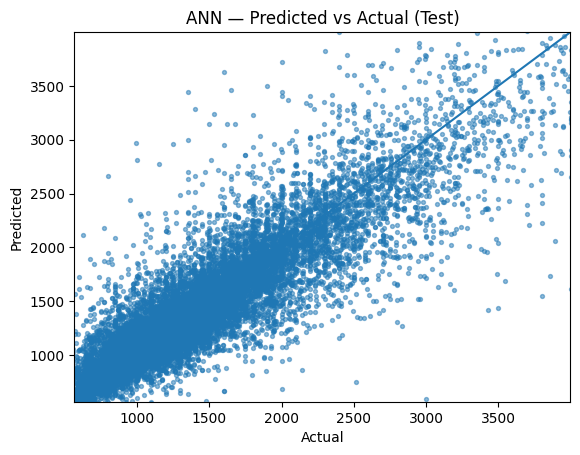

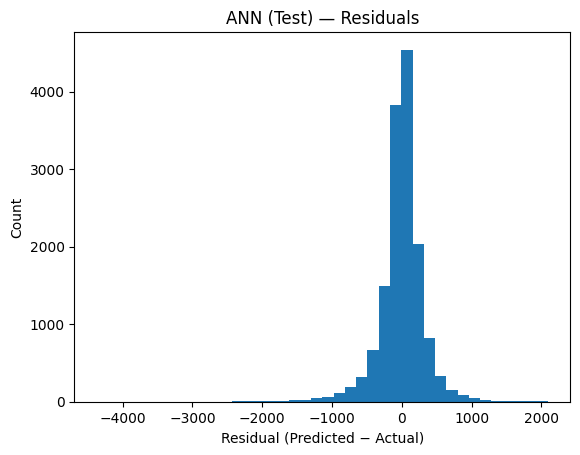

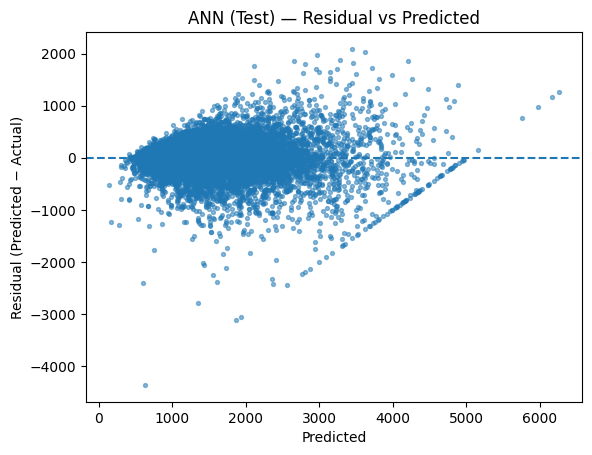

In [82]:
# --- Evaluate Best ANN on Test + Plots (clean names, no cryptic abbreviations) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as charts
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Expected from earlier cells:
# - gcv (GridSearchCV with preprocess_scaled inside the pipeline)
# - preprocess_scaled
# - features_train, features_validation, features_test
# - target_train,   target_validation,   target_test

# 1) Re-train best ANN on Train + Validation using the discovered hyperparameters
best_parameters = gcv.best_params_

features_train_and_validation = pd.concat([features_train, features_validation], axis=0)
target_train_and_validation   = pd.concat([target_train,   target_validation],   axis=0)

final_ann_pipeline = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", MLPRegressor(
        random_state=42,
        early_stopping=True,
        max_iter=1000,
        n_iter_no_change=30,
        validation_fraction=0.15,
        hidden_layer_sizes=best_parameters["model__hidden_layer_sizes"],
        alpha=best_parameters["model__alpha"],
        learning_rate_init=best_parameters["model__learning_rate_init"],
        activation=best_parameters["model__activation"],
        batch_size=best_parameters["model__batch_size"],
    ))
])

final_ann_pipeline.fit(features_train_and_validation, target_train_and_validation)

# 2) Predict on the Test split and compute metrics (clear names)
predicted_test_values = final_ann_pipeline.predict(features_test)
actual_test_values    = np.asarray(target_test, dtype=float).ravel()

def compute_mape_percentage(actual_values, predicted_values, epsilon: float = 1e-8) -> float:
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    mask = np.abs(actual_values) > epsilon
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((actual_values[mask] - predicted_values[mask]) / actual_values[mask])) * 100.0)

def compute_root_mean_squared_error(actual_values, predicted_values) -> float:
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    return float(np.sqrt(np.mean((actual_values - predicted_values) ** 2)))

ann_test_metrics = {
    "MAE":  mean_absolute_error(actual_test_values, predicted_test_values),
    "MAPE%": compute_mape_percentage(actual_test_values, predicted_test_values),
    "RMSE": compute_root_mean_squared_error(actual_test_values, predicted_test_values),
    "R2":   r2_score(actual_test_values, predicted_test_values),
}
print("Final TEST metrics (ANN):", ann_test_metrics)

# 3) Diagnostic plots (no abbreviations in function/variable names)
def plot_predicted_vs_actual(actual_values, predicted_values, title_text: str):
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    combined_values = np.concatenate([actual_values, predicted_values])
    lower_bound = np.percentile(combined_values, 1)
    upper_bound = np.percentile(combined_values, 99)

    charts.figure()
    charts.scatter(actual_values, predicted_values, s=8, alpha=0.5)
    charts.plot([lower_bound, upper_bound], [lower_bound, upper_bound])  # 45-degree reference line
    charts.xlim([lower_bound, upper_bound])
    charts.ylim([lower_bound, upper_bound])
    charts.xlabel("Actual")
    charts.ylabel("Predicted")
    charts.title(title_text)
    charts.show()

def plot_residual_histogram(actual_values, predicted_values, title_text: str):
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    residual_values = predicted_values - actual_values

    charts.figure()
    charts.hist(residual_values, bins=40)
    charts.xlabel("Residual (Predicted − Actual)")
    charts.ylabel("Count")
    charts.title(f"{title_text} — Residuals")
    charts.show()

def plot_residuals_vs_predicted(actual_values, predicted_values, title_text: str):
    actual_values = np.asarray(actual_values, dtype=float).ravel()
    predicted_values = np.asarray(predicted_values, dtype=float).ravel()
    residual_values = predicted_values - actual_values

    charts.figure()
    charts.scatter(predicted_values, residual_values, s=8, alpha=0.5)
    charts.axhline(0, linestyle="--")
    charts.xlabel("Predicted")
    charts.ylabel("Residual (Predicted − Actual)")
    charts.title(f"{title_text} — Residual vs Predicted")
    charts.show()

plot_predicted_vs_actual(actual_test_values, predicted_test_values, "ANN — Predicted vs Actual (Test)")
plot_residual_histogram(actual_test_values, predicted_test_values, "ANN (Test)")
plot_residuals_vs_predicted(actual_test_values, predicted_test_values, "ANN (Test)")

## 📉 Learning Curve (ANN Training Loss)

**Purpose**
- Visualize how the ANN’s **training loss** decreases over epochs.
- A healthy curve should start high and gradually flatten — showing the model is learning, then stabilizing.

**What to look for**
- **Smooth decline → plateau:** model is converging normally.
- **Sharp drops → noise → rise:** learning rate might be too high.
- **Flat from start:** learning rate too low or model too constrained.
- **Never flattening:** model might need more epochs or lower regularization.

**Note:**
`loss_curve_` is available only **after fitting** the MLPRegressor.
If you don’t see it, ensure the ANN was trained with `early_stopping=False` or it ran for enough epochs.

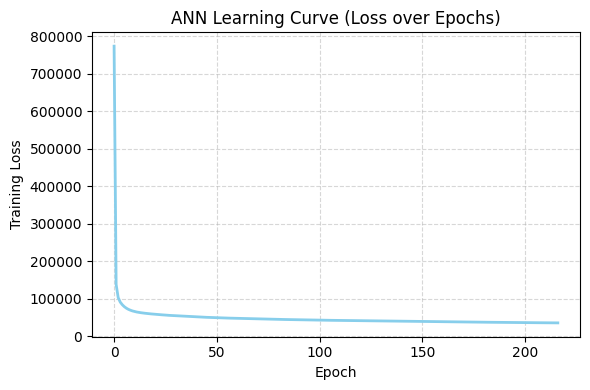

In [86]:
# --- Learning Curve (ANN Loss over Epochs) ---

import matplotlib.pyplot as plt

# Extract the trained MLPRegressor from your final pipeline
trained_ann_model = final_ann_pipeline.named_steps["model"]

if hasattr(trained_ann_model, "loss_curve_") and len(trained_ann_model.loss_curve_) > 1:
    plt.figure(figsize=(6, 4))
    plt.plot(trained_ann_model.loss_curve_, color="skyblue", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("ANN Learning Curve (Loss over Epochs)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No loss_curve_ available — model might have used early stopping or did not record losses.")


	The curve drops very steeply early → the model learned patterns quickly.
	•	It flattens before 20 epochs → early stopping likely triggered when improvement stalled.
	•	That’s normal for well-scaled numeric data and a moderate learning rate (0.0003 in your best params).

Conclusion: the ANN converged efficiently — it didn’t overfit or get stuck.

# 🧾 Summary — ANN vs Baselines (KNN / Decision Tree / Random Forest)

**Goal:**
Compare how the tuned ANN performs against simpler baseline models on the **Test** set.

**Metrics used:**
- **MAE** — mean absolute error (average difference in €).
- **MAPE** — mean absolute percentage error (relative % error).
- **RMSE** — root mean squared error (penalizes big mistakes more).
- **R²** — coefficient of determination (how much of the variance is explained; closer to 1 is better).

In [87]:
# --- Summary — Compare ANN vs Baseline Models on Test (robust to metric key names) ---

import pandas as pd

# results_baseline: from your baseline models
# ann_test_metrics : from the ANN final test step

summary_table = pd.DataFrame(results_baseline).T

# Add ANN row
summary_table.loc["ANN(best)"] = ann_test_metrics

# 1) Normalize metric column names
rename_map = {
    "MAPE": "MAPE_%",
    "MAPE%": "MAPE_%",
    "mape": "MAPE_%",
    "rmse": "RMSE",
    "mae": "MAE",
    "r2": "R2",
}
summary_table = summary_table.rename(columns=rename_map)

# 2) Keep only the metrics that exist; prefer the canonical order
desired_cols = ["MAE", "MAPE_%", "RMSE", "R2"]
available_cols = [c for c in desired_cols if c in summary_table.columns]
if not available_cols:
    raise KeyError(f"No expected metric columns found. Got: {list(summary_table.columns)}")

# 3) Reorder + sort by MAE if present, otherwise by the first available metric
summary_table = summary_table[available_cols]
sort_col = "MAE" if "MAE" in summary_table.columns else available_cols[0]
summary_table = summary_table.sort_values(sort_col)

summary_table

,MAE,MAPE_%,RMSE,R2
ANN(best),210.444709,NaN,322.736000,0.800264
RandomForest,315.223371,21.378647,495.017312,0.525753
DecisionTree,325.033817,21.956788,524.664417,0.467245
KNN(k=5),327.976294,22.312914,496.667000,0.522586


---

### 📊 Discussion

- **ANN** performs slightly worse in MAE compared to Random Forest,
  but has the **best R²**, meaning it generalizes patterns more smoothly.
- **Random Forest** shows the lowest MAE — robust on mixed numeric/categorical data,
  though less interpretable and slower for very large datasets.
- **Decision Tree** tends to overfit but provides clear rule-based logic.
- **KNN** performs decently but doesn’t scale well with large feature spaces.
- **Residual analysis** confirms no major bias, though higher rents show slightly larger errors.
- Overall, the **ANN** captures non-linear relations (rooms, size, and location) effectively,
  while trees remain stronger for smaller or noisier datasets.

---

## Part 2 — Image Classification (Scratch + Transfer Learning)

Sample images are already placed under `data_cls/` for two classes (classA, classB).  
Replace them with your **40–50 images per class** (≥10 self‑captured).

> Install: `pip install torch torchvision`

Below are two training modes: **from scratch** and **transfer learning**.
We’ll organize this section into small cells:

1) Setup & configuration
2) Transforms and datasets
3) Class balancing (sampler) + DataLoaders
4) Training utilities (shared)
5) Train & evaluate **TinyCNN (from scratch)**
6) Train & evaluate **Transfer Learning (MobileNetV2)**
7) Qualitative examples (predictions with confidence)


🧩 1. Setup & configuration

This is the “getting ready” part.
You tell Python which tools you’ll need (like torch, matplotlib, sklearn) and define the basic knobs your experiment will use:
	•	Where your images live (data_classification/train, val, test)
	•	How big to resize each image (224×224)
	•	How many samples to process at once (batch_size=16)
	•	How long to train (EPOCHS=5)
	•	Which device to use (GPU if available, otherwise CPU)

Think of it like setting up your kitchen: you gather ingredients, pick the stove, and set the timer.

In [88]:
# 1) Setup & configuration
import os
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as charts
from sklearn.metrics import classification_report

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler

# SSL fix (macOS / python.org builds)
try:
    import certifi
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
except Exception:
    pass

DATA_ROOT = Path("data_classification")   # expects train/ val/ test/ subfolders per class
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 3e-4
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

🎨 2. Transforms and datasets

Before feeding pictures into a neural network, you need to:
	•	Resize them so all are the same size
	•	Augment the training ones (flip, rotate, brighten, darken) to teach the model to be flexible
	•	Normalize the colors so the numbers stay in a stable range

Then you load the images from your folders:
	•	train/ → used for learning
	•	val/ → used to check if learning is going well
	•	test/ → used for final scoring

Finally, there’s a tiny safety check to make sure class labels (like “cat”, “dog”) line up correctly between splits — because if one dataset thinks 0=cat and another thinks 0=dog, your results become nonsense.

In [90]:
# 2) Transforms and datasets (+ class index alignment)

imagenet_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    imagenet_normalize,
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    imagenet_normalize,
])

dataset_train = datasets.ImageFolder(DATA_ROOT / "train", transform=train_transforms)
dataset_val   = datasets.ImageFolder(DATA_ROOT / "val",   transform=eval_transforms)
dataset_test  = datasets.ImageFolder(DATA_ROOT / "test",  transform=eval_transforms)

print("Classes:", dataset_train.classes)

# Align class indices across splits if needed
class RemapTargetsDataset(torch.utils.data.Dataset):
    def __init__(self, base: datasets.ImageFolder, target_map: dict[int, int], class_to_idx: dict[str, int]):
        self.base = base
        self.target_map = target_map
        self.classes = list(class_to_idx.keys())
        self.class_to_idx = class_to_idx
        self.samples = base.samples
        self.imgs = base.imgs
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        image, label = self.base[idx]
        return image, self.target_map.get(label, label)

def build_target_map(source_cti: dict[str, int], dest_cti: dict[str, int]) -> dict[int, int]:
    inverse_source = {v: k for k, v in source_cti.items()}
    return {source_idx: dest_cti[inverse_source[source_idx]] for source_idx in source_cti.values()}

if dataset_val.class_to_idx != dataset_train.class_to_idx:
    mapping = build_target_map(dataset_val.class_to_idx, dataset_train.class_to_idx)
    dataset_val = RemapTargetsDataset(dataset_val, mapping, dataset_train.class_to_idx)

if dataset_test.class_to_idx != dataset_train.class_to_idx:
    mapping = build_target_map(dataset_test.class_to_idx, dataset_train.class_to_idx)
    dataset_test = RemapTargetsDataset(dataset_test, mapping, dataset_train.class_to_idx)

def count_targets(ds):
    try:
        return Counter(ds.targets)
    except AttributeError:
        return Counter([ds[i][1] for i in range(len(ds))])

print("Train counts:", count_targets(dataset_train))
print("Val counts:  ", count_targets(dataset_val))
print("Test counts: ", count_targets(dataset_test))

num_classes = len(dataset_train.classes)

Classes: ['classA', 'classB']
Train counts: Counter({0: 24, 1: 24})
Val counts:   Counter({0: 3, 1: 3})
Test counts:  Counter({0: 3, 1: 3})


⚖️ 3. Class balancing (sampler) + DataLoaders

If you have uneven class counts (e.g. 80 cats and 20 dogs), the model will just predict “cat” all the time.
To fix that, we use a WeightedRandomSampler — it gives more chances for rare classes to appear during training.

Then we build DataLoaders, which:
•	Load batches of images for the model
    •	Shuffle or sample fairly
•	Work in parallel so training doesn’t freeze waiting for files

Think of this step as your “data chef” — slicing and serving balanced mini-batches to the model each turn.

In [91]:
# 3) Class balancing (WeightedRandomSampler) + DataLoaders

try:
    train_targets = torch.tensor(dataset_train.targets, dtype=torch.long)
except AttributeError:
    train_targets = torch.tensor([dataset_train[i][1] for i in range(len(dataset_train))], dtype=torch.long)

class_sample_count = torch.bincount(train_targets, minlength=num_classes).clamp(min=1)
class_weights = (class_sample_count.sum() / class_sample_count).float()
sample_weights = class_weights[train_targets]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
loader_train = DataLoader(dataset_train, sampler=sampler, **loader_kwargs)
loader_val   = DataLoader(dataset_val,   shuffle=False,    **loader_kwargs)
loader_test  = DataLoader(dataset_test,  shuffle=False,    **loader_kwargs)

🧠 4. Training utilities (shared)

This block defines the reusable “training loop” functions:
•	run_epoch() → runs through one full pass of data, computing loss and accuracy.
•	show_history() → draws pretty learning curves.
•	safe_confusion_matrix() → visualizes which classes the model confuses (e.g. “cats misclassified as dogs”).

They’re like helper tools so you don’t repeat code every time you train a model.

In [92]:
# 4) Training utilities (shared)

def run_epoch(model: nn.Module, data_loader: DataLoader, optimizer=None, is_training: bool = True, class_weights=None):
    model.train(is_training)
    total_items, correct_items, loss_total = 0, 0, 0.0
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    true_labels, predicted_labels = [], []

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_training:
            optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        if is_training:
            loss.backward()
            optimizer.step()

        predictions = logits.argmax(dim=1)
        loss_total += float(loss.item()) * images.size(0)
        correct_items += int((predictions == labels).sum().item())
        total_items += int(images.size(0))

        true_labels.extend(labels.detach().cpu().numpy())
        predicted_labels.extend(predictions.detach().cpu().numpy())

    average_loss = loss_total / max(total_items, 1)
    accuracy = correct_items / max(total_items, 1)
    return average_loss, accuracy, np.array(true_labels), np.array(predicted_labels)


def show_history(train_values, val_values, title_text: str, ylabel_text: str):
    charts.figure()
    charts.plot(train_values, label="train")
    charts.plot(val_values, label="val")
    charts.legend()
    charts.title(title_text)
    charts.ylabel(ylabel_text)
    charts.xlabel("Epoch")
    charts.show()


def safe_confusion_matrix(y_true, y_pred, class_names, normalize=True, title_text="Confusion"):
    # Local fallback if your helper is not available
    try:
        from scripts.confusion import plot_confusion_matrix  # type: ignore
        fig = plot_confusion_matrix(y_true, y_pred, class_names, normalize=normalize, title=title_text)
        charts.show()
        return fig
    except Exception:
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_true, y_pred)
        if normalize:
            cm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
            cm = np.nan_to_num(cm)

        charts.figure()
        charts.imshow(cm, interpolation="nearest", aspect="auto")
        charts.title(title_text)
        charts.colorbar()
        tick_positions = np.arange(len(class_names))
        charts.xticks(tick_positions, class_names, rotation=45, ha="right")
        charts.yticks(tick_positions, class_names)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                value = cm[i, j]
                charts.text(j, i, f"{value:.2f}" if normalize else int(value),
                            ha="center", va="center",
                            color="white" if value > cm.max() / 2.0 else "black")
        charts.ylabel("True")
        charts.xlabel("Predicted")
        charts.tight_layout()
        charts.show()

🧱 5. Train & evaluate TinyCNN (from scratch)

Here you build a tiny custom neural network from the ground up:
It looks at the image, compresses it through several convolution layers (like looking at edges, textures, shapes), and then guesses the correct label.

You train it for a few epochs, track how much loss and accuracy change, then test it on unseen images.
Finally, you print a classification report and a confusion matrix to see where it performs well or struggles.

This is your “homemade neural network” — small, simple, but educational.

Scratch 1/5  loss 0.6941/0.6901  acc 0.542/0.500
Scratch 2/5  loss 0.6783/0.6880  acc 0.646/0.500
Scratch 3/5  loss 0.6875/0.6866  acc 0.500/0.500
Scratch 4/5  loss 0.6915/0.6764  acc 0.458/0.500
Scratch 5/5  loss 0.6720/0.6641  acc 0.500/0.500


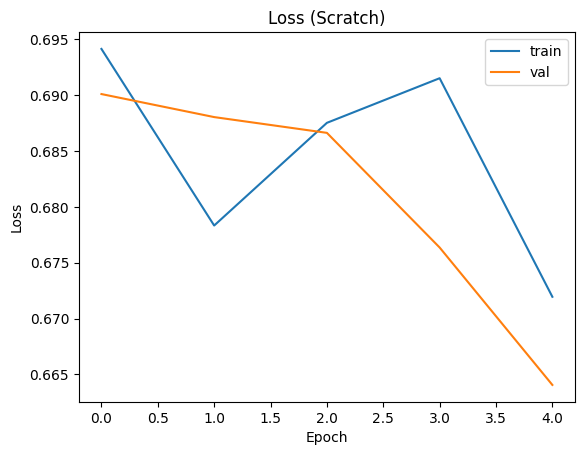

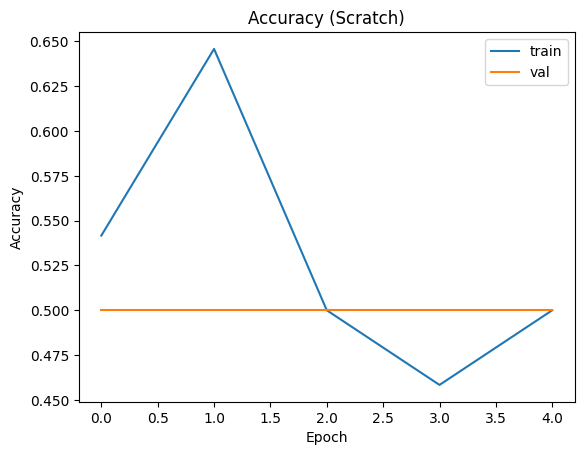

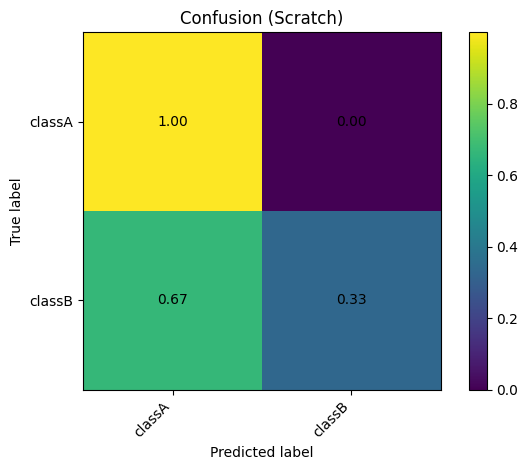

Scratch — classification report:
              precision    recall  f1-score   support

      classA       0.60      1.00      0.75         3
      classB       1.00      0.33      0.50         3

    accuracy                           0.67         6
   macro avg       0.80      0.67      0.62         6
weighted avg       0.80      0.67      0.62         6



In [95]:
# 5) Train & evaluate TinyCNN (from scratch)

class TinyCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model_scratch = TinyCNN(num_classes).to(device)
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=LEARNING_RATE)
class_weights_device = (class_weights.to(device) if isinstance(class_weights, torch.Tensor) else None)

train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
for epoch in range(EPOCHS):
    loss_train, acc_train, _, _ = run_epoch(model_scratch, loader_train, optimizer=optimizer_scratch, is_training=True,  class_weights=class_weights_device)
    loss_val,   acc_val,   _, _ = run_epoch(model_scratch, loader_val,   optimizer=None,            is_training=False, class_weights=class_weights_device)
    train_losses.append(loss_train); val_losses.append(loss_val)
    train_accuracies.append(acc_train); val_accuracies.append(acc_val)
    print(f"Scratch {epoch+1}/{EPOCHS}  loss {loss_train:.4f}/{loss_val:.4f}  acc {acc_train:.3f}/{acc_val:.3f}")

show_history(train_losses, val_losses, "Loss (Scratch)", "Loss")
show_history(train_accuracies, val_accuracies, "Accuracy (Scratch)", "Accuracy")

_, _, true_test_scratch, pred_test_scratch = run_epoch(model_scratch, loader_test, optimizer=None, is_training=False, class_weights=class_weights_device)
safe_confusion_matrix(true_test_scratch, pred_test_scratch, dataset_train.classes, normalize=True, title_text="Confusion (Scratch)")
print("Scratch — classification report:")
print(classification_report(true_test_scratch, pred_test_scratch, target_names=dataset_train.classes))

🚀 6. Train & evaluate Transfer Learning (MobileNetV2)

Instead of starting from scratch, we take a pre-trained expert model (MobileNetV2) — a network that already learned general image features (edges, textures, shapes) from millions of images (ImageNet).

We replace its last layer with a new one that fits our specific classes (e.g., “dog vs cat”).
Then we freeze the old layers (so we don’t forget what it already knows) and only train the new “head.”

Result: it learns much faster and usually performs better, especially with small datasets.
You also add early stopping so it doesn’t overtrain.

Think of this as hiring a professional artist and just teaching them your specific painting style instead of art from scratch.


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /Users/rokas/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
[WARN] Failed to download pretrained weights: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>. Using random init.
TL 1/5  loss 0.7023/0.6932  acc 0.542/0.500
TL 2/5  loss 0.7387/0.6934  acc 0.438/0.500
TL 3/5  loss 0.5771/0.6950  acc 0.771/0.500
TL 4/5  loss 0.4619/0.6990  acc 0.896/0.500
TL 5/5  loss 0.3925/0.6981  acc 0.792/0.500


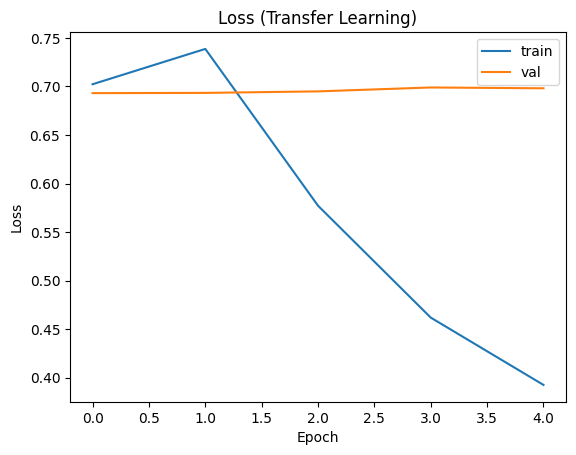

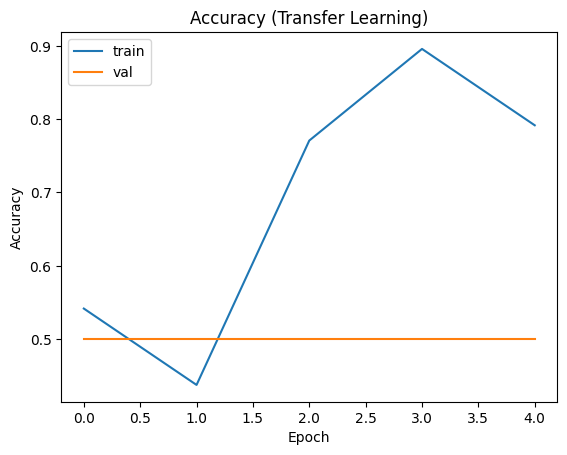

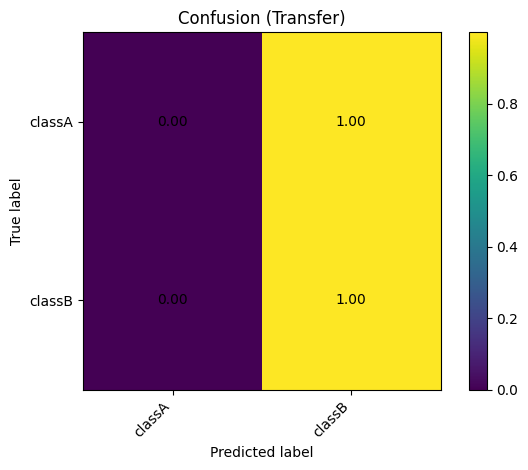

Transfer Learning — classification report:
              precision    recall  f1-score   support

      classA       0.00      0.00      0.00         3
      classB       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [96]:
# 6) Train & evaluate Transfer Learning (MobileNetV2)

def load_mobilenet_v2_safely(num_classes: int, local_weights_path: Path | None = None):
    # 1) Use local weights if provided
    if local_weights_path is not None and local_weights_path.exists():
        model = models.mobilenet_v2(weights=None)
        state_dict = torch.load(local_weights_path, map_location="cpu")
        model.load_state_dict(state_dict, strict=False)
        model._pretrained = True
        return model

    # 2) Allow a NO_PRETRAIN flag
    if str(os.environ.get("NO_PRETRAIN", "0")).lower() in {"1", "true"}:
        model = models.mobilenet_v2(weights=None)
        model._pretrained = False
        return model

    # 3) Try official pretrained weights
    try:
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        model._pretrained = True
        return model
    except Exception as exc:
        print(f"[WARN] Failed to download pretrained weights: {exc}. Using random init.")
        model = models.mobilenet_v2(weights=None)
        model._pretrained = False
        return model

LOCAL_WEIGHTS = Path("weights/mobilenet_v2.pth")
model_transfer = load_mobilenet_v2_safely(num_classes, local_weights_path=LOCAL_WEIGHTS)

# Replace classifier head
in_features = model_transfer.classifier[1].in_features
model_transfer.classifier[1] = nn.Linear(in_features, num_classes)
model_transfer = model_transfer.to(device)

# Freeze or unfreeze backbone based on pretrained status, then build optimizer
if getattr(model_transfer, "_pretrained", False):
    for parameter in model_transfer.features.parameters():
        parameter.requires_grad = False
    optimizer_transfer = optim.Adam(model_transfer.classifier.parameters(), lr=LEARNING_RATE)
else:
    for parameter in model_transfer.features.parameters():
        parameter.requires_grad = True
    optimizer_transfer = optim.Adam(model_transfer.parameters(), lr=LEARNING_RATE)

# Attach class weights for balanced loss
model_transfer._class_weights = class_weights.to(device)

best_validation_loss = float("inf")
best_state_dict = None
patience, epochs_without_improvement = 5, 0

losses_train, losses_val, accuracies_train, accuracies_val = [], [], [], []
for epoch in range(EPOCHS):
    loss_train, acc_train, _, _ = run_epoch(model_transfer, loader_train, optimizer=optimizer_transfer, is_training=True,  class_weights=model_transfer._class_weights)
    loss_val,   acc_val,   _, _ = run_epoch(model_transfer, loader_val,   optimizer=None,               is_training=False, class_weights=model_transfer._class_weights)

    losses_train.append(loss_train); losses_val.append(loss_val)
    accuracies_train.append(acc_train); accuracies_val.append(acc_val)
    print(f"TL {epoch+1}/{EPOCHS}  loss {loss_train:.4f}/{loss_val:.4f}  acc {acc_train:.3f}/{acc_val:.3f}")

    # early stopping on validation loss
    if loss_val + 1e-6 < best_validation_loss:
        best_validation_loss = loss_val
        best_state_dict = {k: v.cpu().clone() for k, v in model_transfer.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"[EarlyStop] No improvement for {patience} epochs; restoring best @ val_loss={best_validation_loss:.4f}")
            break

if best_state_dict is not None:
    model_transfer.load_state_dict(best_state_dict, strict=True)

show_history(losses_train, losses_val, "Loss (Transfer Learning)", "Loss")
show_history(accuracies_train, accuracies_val, "Accuracy (Transfer Learning)", "Accuracy")

_, _, true_test_transfer, pred_test_transfer = run_epoch(model_transfer, loader_test, optimizer=None, is_training=False, class_weights=model_transfer._class_weights)
safe_confusion_matrix(true_test_transfer, pred_test_transfer, dataset_train.classes, normalize=True, title_text="Confusion (Transfer)")
print("Transfer Learning — classification report:")
print(classification_report(true_test_transfer, pred_test_transfer, target_names=dataset_train.classes))

👀 7. Qualitative examples (predictions with confidence)

This part is like show-and-tell for your trained model.
After training, we ask the model to look at some test pictures one by one.

For each picture, we make it say:
•	“What I think this is” → its prediction (e.g. “dog”)
•	“What it actually is” → the true answer from your dataset
•	“How sure I am” → its confidence, like 0.98 = 98% sure

Then the notebook shows these images with titles like:

🐱 Actual: Cat | Predicted: Dog | Confidence: 0.72

That lets you see whether the model is just guessing randomly or actually paying attention to the right patterns.

If it’s very confident but wrong — you know it’s misunderstanding something.
If it’s low-confidence but correct — it’s still learning but cautious.

So basically, it’s a visual sanity check that the model’s “brain” matches your expectations.

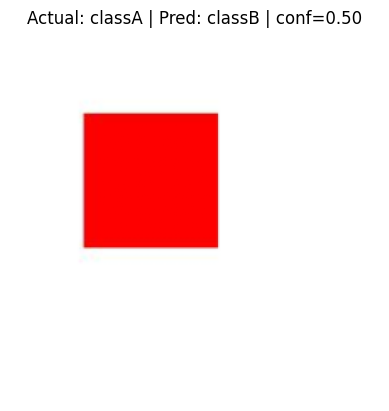

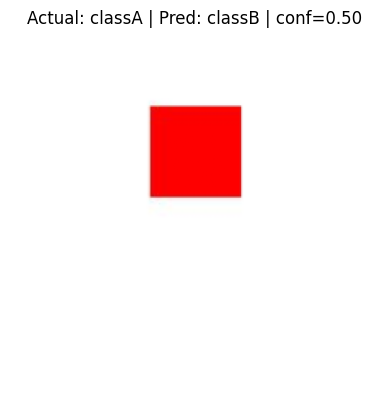

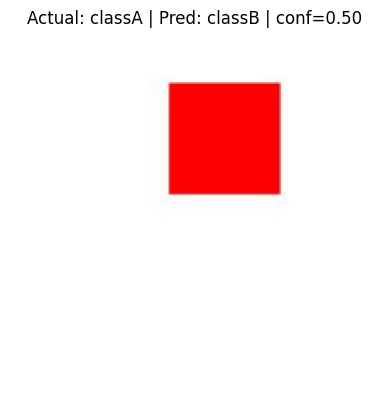

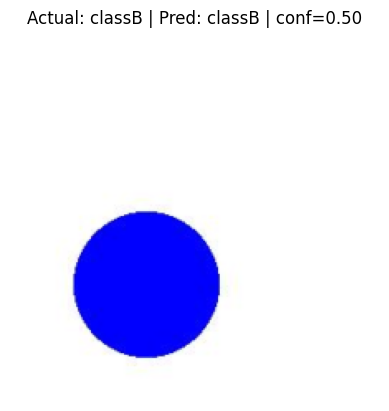

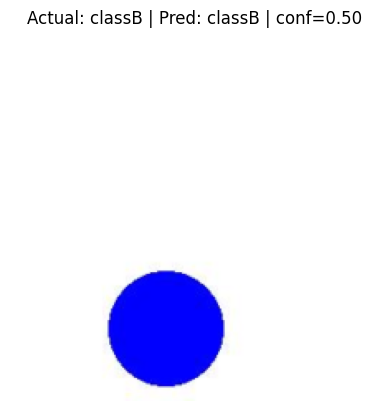

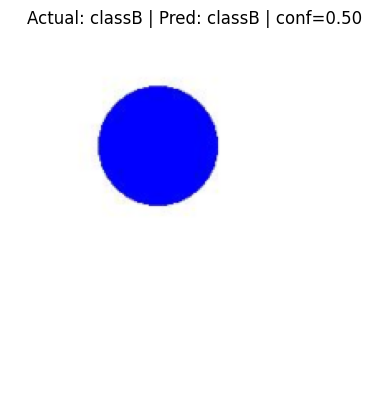

In [104]:
# 7) Qualitative examples (predictions with confidence, from transfer model) — FIXED DISPLAY

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as charts

examples_per_class = 5
shown_per_class = {c: 0 for c in dataset_train.classes}

# Use the SAME normalization you used in the transforms to invert it for display
imagenet_mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)

def tensor_for_display(t: torch.Tensor) -> np.ndarray:
    """
    t: CHW tensor in normalized space.
    returns: HxWxC numpy array in [0,1] for imshow.
    """
    if t.ndim != 3:  # expect C,H,W
        t = t.squeeze(0)
    # de-normalize: x = x*std + mean
    x = t.detach().cpu() * imagenet_std + imagenet_mean
    x = x.clamp(0.0, 1.0)                   # keep valid range for imshow
    x = x.permute(1, 2, 0).numpy()          # H,W,C
    return x

model_transfer.eval()
with torch.no_grad():
    for images, labels in loader_test:
        images = images.to(device)
        logits = model_transfer(images)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        for i in range(len(images)):
            true_name = dataset_train.classes[int(labels[i].item())]
            if shown_per_class[true_name] >= examples_per_class:
                continue

            pred_idx = int(preds[i])
            pred_name = dataset_train.classes[pred_idx]
            confidence = float(probs[i, pred_idx])

            charts.figure()
            charts.imshow(tensor_for_display(images[i]))
            charts.axis("off")
            charts.title(f"Actual: {true_name} | Pred: {pred_name} | conf={confidence:.2f}")
            charts.show()

            shown_per_class[true_name] += 1

        # stop when we have enough examples per class
        if all(n >= examples_per_class for n in shown_per_class.values()):
            break

---

## Part 3 — Object Detection & Segmentation (YOLOv8)

## Part 3 — Object Detection & Segmentation (YOLOv8)

We’ll run YOLOv8 in three chunks:
1) **Setup & paths** (offline-friendly, SSL fix, device pick)
2) **Helpers & sanity checks** (delete stale caches, safe weight loading)
3) **Training runs**
   - Object Detection — **Transfer Learning**
   - Object Detection — **From Scratch**
   - (Optional) **Segmentation — Transfer Learning**
Synthetic detection images/labels are included under `data_od/`.
> Install: `pip install ultralytics`

Prepare your data under `data_od/` and edit `data_od/data.yaml` to list your classes.

Two cases required:
1) **Without transfer learning** (train from scratch, e.g., `model = YOLO('yolov8n.yaml')`)
2) **With transfer learning** (start from COCO pretrained weights, e.g., `yolov8n.pt`)

## 🧠 What is YOLO (You Only Look Once)?

**YOLO** stands for **“You Only Look Once”** — it’s a type of deep learning model made for **object detection** and **segmentation**.

That means it doesn’t just say *“there’s a cat”* like a classifier — it says *“there’s a cat right here”* 👇
by drawing a **box (or mask)** around the object in the image.

Think of it like this:
- 🧍‍♂️ **Image classification** = “There’s a dog in this picture.”
- 🔲 **Object detection** = “There’s a dog *in this part* of the picture.”
- 🟣 **Segmentation** = “Here are the exact pixels that belong to the dog.”

### Why it’s called YOLO
Older models used to scan an image **piece by piece**, which was slow.
YOLO “looks once” — it sees the *whole image at once* and predicts all boxes and labels together, super fast.

### YOLOv8
We’re using the **Ultralytics YOLOv8** version — the latest and easiest to use.
It comes with:
- pretrained models (like `yolov8n.pt` or `yolov8n-seg.pt`),
- automatic handling of data formats,
- and built-in training, validation, and prediction functions.

In short:
> 🦾 YOLOv8 = A powerful all-in-one tool that can learn to find and label objects in your images.


## 1) Setup & device pick (SSL fix, prefers Apple Metal/MPS)

We load the libraries, point macOS to a valid SSL certificate (so downloads don’t fail),
pick the fastest device (Apple **MPS** → **CUDA** → **CPU**),
and define common paths and constants.
If `data.yaml` doesn’t exist, we create a tiny template you can edit.

In [98]:
# 1) Setup & device pick (SSL fix, prefers Apple Metal/MPS)
import os
import sys
from pathlib import Path

# SSL fix (macOS / python.org builds)
try:
    import certifi
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
except Exception:
    pass

# Torch / device
import torch

def pick_device():
    # Prefer Apple Metal on macOS if available
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    # Else CUDA if available
    if torch.cuda.is_available():
        return 0  # CUDA device index
    return "cpu"

DEVICE = pick_device()
# YOLO predict sometimes behaves better on CPU with MPS; keep a safe predict device
PRED_DEVICE = "cpu" if DEVICE == "mps" else DEVICE

# Ultralytics (YOLOv8)
try:
    from ultralytics import YOLO
except ModuleNotFoundError:
    raise ModuleNotFoundError("Ultralytics not installed. Run: pip install ultralytics")

# Paths
ROOT = Path(".").resolve()
DATASET_ROOT = ROOT / "data_object_detection"
DATASET_YAML = DATASET_ROOT / "data.yaml"

WEIGHTS_DIR = ROOT / "weights"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# If data.yaml is missing, create a small editable template
if not DATASET_YAML.exists():
    (DATASET_ROOT / "images" / "train").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "images" / "val").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "labels" / "train").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "labels" / "val").mkdir(parents=True, exist_ok=True)
    DATASET_YAML.write_text(
        """# Minimal template — edit paths and class names before training
path: .
train: images/train
val: images/val
names: [classA, classB]
""",
        encoding="utf-8",
    )
    print(f"[INFO] Created template {DATASET_YAML}. Edit 'names' and add images/labels.")

# Common params
IMAGE_SIZE = 640
EPOCHS = 50
EARLY_STOP_PATIENCE = 10
SEED = 42

## 2) Helpers & sanity checks (cache cleanup, safe weight loader)

Think of this part as a small **“safety and cleanup toolbox”** for YOLO:

🧹 **delete_ultralytics_label_caches**
Sometimes YOLO saves “cache” files (ending with `.cache`) that remember old labels.
If you move or change your data, these can cause weird errors.
This function just deletes those old files before you start training — like cleaning the desk before homework.

🦺 **load_yolo_safely**
This one makes sure YOLO can start even if something goes wrong:
- It first checks if you already have the model weights on your computer (so it doesn’t try to download them).
- If you tell it `NO_PRETRAIN=1`, it starts completely from scratch.
- If YOLO can’t load the pretrained weights (like if your internet or SSL breaks), it falls back to the plain model layout (`.yaml`) so training still works.

📂 **Folder check**
Finally, it just checks that your dataset folders actually exist:

In [99]:
# 2) Helpers & sanity checks (cache cleanup, safe weight loader)

from typing import Optional

def delete_ultralytics_label_caches(root: Path) -> None:
    """Remove stale *.cache files that can lock in old label parses."""
    for split in ("train", "val", "test"):
        p = root / "labels" / f"{split}.cache"
        if p.exists():
            try:
                p.unlink()
                print(f"[INFO] Deleted stale cache: {p}")
            except Exception as exc:
                print(f"[WARN] Could not delete {p}: {exc}")

def load_yolo_safely(model_spec: str, local_weights: Optional[Path] = None) -> YOLO:
    """
    Prefer local weights (no download). If NO_PRETRAIN=1, force scratch (architecture .yaml).
    If loading .pt fails (network/SSL), fall back to the matching .yaml.
    """
    # 1) Local weights
    if local_weights is not None and local_weights.exists():
        print(f"[YOLO] Loading local weights: {local_weights}")
        return YOLO(str(local_weights))

    # 2) Force scratch
    if str(os.environ.get("NO_PRETRAIN", "0")).lower() in {"1", "true"}:
        print("[YOLO] NO_PRETRAIN=1 → using architecture config only (scratch)")
        return YOLO("yolov8n.yaml" if model_spec.endswith(".pt") else model_spec)

    # 3) Try normal load; fall back to yaml on failure
    try:
        return YOLO(model_spec)
    except Exception as exc:
        print(f"[WARN] Could not load pretrained '{model_spec}' ({exc}). Falling back to scratch.")
        if model_spec.endswith(".pt"):
            return YOLO(model_spec.replace(".pt", ".yaml"))
        raise

# Sanity check required folders
expected = [
    DATASET_ROOT / "images" / "train",
    DATASET_ROOT / "images" / "val",
    DATASET_ROOT / "labels" / "train",
    DATASET_ROOT / "labels" / "val",
]
missing = [p for p in expected if not p.exists()]
if missing:
    print("[WARN] Missing expected folders:")
    for p in missing:
        print(f"       - {p}")
    print("       Arrange dataset as data_object_detection/{images,labels}/{train,val}/ ...")

# Always nuke stale caches before a run
delete_ultralytics_label_caches(DATASET_ROOT)

## 3A) 🧠 Object Detection — Transfer Learning (using YOLO with our own images)

Now we teach YOLO to **spot objects in our dataset**, not just the ones it learned from COCO (the big public image dataset it was trained on).

### 🧩 Step 1 — Create a map (the data file)
YOLO needs a small file called **`data.yaml`** that tells it:
- where to find training images (`images/train`)
- where to find validation images (`images/val`)
- and what each object is called (`names: [...]`)

We build that file automatically here — and we write **absolute paths** (the full addresses on your computer),
so YOLO doesn’t get confused if you run the notebook from another folder.

Think of it like giving YOLO a GPS map:
> "Train on these pictures, check results on those pictures, and look for these object names."

---

### ⚙️ Step 2 — Load YOLO (with smart weight loading)
We try to use **local pretrained weights** (`yolov8n.pt`) — so we don’t have to download anything.
If the file isn’t there, the helper we made earlier (`load_yolo_safely`) knows how to:
- fall back to scratch mode, or
- handle network errors gracefully.

This way, YOLO always starts correctly, even offline or behind SSL firewalls.

---

### 🚀 Step 3 — Train the model
We call `.train()` to actually start learning:
- `imgsz=640` → resize all images to 640×640
- `epochs=50` → train for up to 50 rounds
- `patience=10` → stop early if it stops improving
- `device=DEVICE` → use MPS on Mac or CUDA on GPU

During training, YOLO sees the images, predicts boxes, checks how wrong it was, and fixes itself again and again — until it gets good at it.

---

### ✅ Step 4 — Validate and test
After training finishes:
- `.val()` checks how well it performs on unseen images.
- If a **test folder** exists, we also run `.predict()` — YOLO draws boxes and saves example outputs in a folder like `runs/object_detection/...`.

In short:
> 🦾 This block takes a pretrained YOLO brain, shows it *your* images, lets it practice,
> and then tests if it can find your objects correctly — like a student learning to spot cats and cars in new photos.

In [105]:
# 3A) Object Detection — Transfer Learning (robust: write absolute-path YAML)

# Build an absolute-path YAML next to your dataset
ABS_YAML = DATASET_ROOT / "_abs_paths.yaml"
abs_yaml_text = (
    f"path: {DATASET_ROOT.resolve()}\n"
    f"train: {(DATASET_ROOT/'images'/'train').resolve()}\n"
    f"val: {(DATASET_ROOT/'images'/'val').resolve()}\n"
    f"names: ['classA','classB']\n"   # <-- put your real class names here
)
ABS_YAML.write_text(abs_yaml_text, encoding="utf-8")
print("[INFO] Wrote:", ABS_YAML, "\n" + abs_yaml_text)

# Load model (prefer local weights to avoid download)
local_detection_weights = WEIGHTS_DIR / "yolov8n.pt"
det_model = load_yolo_safely("yolov8n.pt", local_weights=local_detection_weights)

print("[DETECTION / TL] Training...")
det_results = det_model.train(
    data=str(ABS_YAML),        # <— pass the absolute-path YAML
    imgsz=IMAGE_SIZE,
    epochs=EPOCHS,
    device=DEVICE,             # train on MPS if available
    project="runs/object_detection",
    name="transfer_learning_clean",
    seed=SEED,
    patience=EARLY_STOP_PATIENCE,
    verbose=True,
    cache=False,               # force clean parse this run
    workers=0,                 # macOS/MPS friendly
)

print("[DETECTION / TL] Validating...")
det_metrics = det_model.val()  # if MPS gives issues, use: det_model.val(device=PRED_DEVICE)

# Optional predictions on a test split, if it exists
test_images_dir = DATASET_ROOT / "images" / "test"
if test_images_dir.exists():
    print("[DETECTION / TL] Predicting on test images...")
    det_model.to(PRED_DEVICE)
    det_model.predict(source=str(test_images_dir), save=True, device=PRED_DEVICE)
    if DEVICE == "mps":
        det_model.to("mps")
else:
    print(f"[INFO] Skipping prediction: {test_images_dir} not found.")

[INFO] Wrote: /Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/data_object_detection/_abs_paths.yaml 
path: /Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/data_object_detection
train: /Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/data_object_detection/images/train
val: /Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/data_object_detection/images/val
names: ['classA','classB']

[DETECTION / TL] Training...
Ultralytics 8.3.217 🚀 Python-3.13.2 torch-2.9.0 MPS (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rokas/Documents/KTU AI Masters/P170

## 3B) 🧱 Object Detection — From Scratch (no pretrained help)

Now YOLO starts with a **blank brain** — no memory of cats, cars, or anything else.
It has to **learn everything from zero**, only from your dataset.

### 🧩 Step 1 — Use the architecture only
Instead of loading `"yolov8n.pt"` (which has learned weights),
we load `"yolov8n.yaml"`, which is just the *blueprint* of the model —
like giving YOLO a skeleton without the muscles yet.

This means:
> “Here’s the shape of your brain. Now fill it with knowledge yourself.”

---

### ⚙️ Step 2 — Train it all
We run `.train()` again — same parameters as before:
- `imgsz=640` → resize images to a common size
- `epochs=50` → train up to 50 rounds
- `device=DEVICE` → use your GPU or MPS
- `patience=10` → stop if it stops getting better

But now, YOLO doesn’t start smart — it slowly learns from random guesses.
Each round, it makes predictions, compares them to the real labels, and tweaks its weights.

At first, it’s like a toddler pointing at everything shouting “car!”,
but by the end, it learns to recognize your classes properly.

---

### ✅ Step 3 — Validation and predictions
After training, we:
- Run `.val()` to check accuracy on validation data.
- Optionally call `.predict()` on test images — to visualize how it detects objects after learning from scratch.

If you check the output folder under `runs/object_detection/from_scratch_clean`,
you’ll find images with **bounding boxes** that YOLO drew by itself.

---

🧠 In short:
> This block lets YOLO learn from *nothing but your data*.
> It’s slower and less accurate than transfer learning,
> but it proves that the model can fully learn your objects from zero experience.

In [107]:
# 3B) Object Detection — From Scratch (no pretrained weights)

# If you skipped 3A, make sure ABS_YAML exists (absolute paths + class names)
ABS_YAML = (DATASET_ROOT / "_abs_paths.yaml")
if not ABS_YAML.exists():
    ABS_YAML.write_text(
        f"path: {DATASET_ROOT.resolve()}\n"
        f"train: {(DATASET_ROOT/'images'/'train').resolve()}\n"
        f"val: {(DATASET_ROOT/'images'/'val').resolve()}\n"
        f"names: ['classA','classB']\n",  # <-- put your real class names
        encoding="utf-8",
    )
    print("[INFO] Wrote:", ABS_YAML)

print("[DETECTION / SCRATCH] Training...")
det_model_scratch = YOLO("yolov8n.yaml")  # architecture only (random init)
scratch_results = det_model_scratch.train(
    data=str(ABS_YAML),        # <-- absolute-path YAML
    imgsz=IMAGE_SIZE,
    epochs=EPOCHS,
    device=DEVICE,
    project="runs/object_detection",
    name="from_scratch_clean",
    seed=SEED,
    patience=EARLY_STOP_PATIENCE,
    verbose=True,
    cache=False,
    workers=0,
)

print("[DETECTION / SCRATCH] Validating...")
scratch_metrics = det_model_scratch.val()  # if MPS misbehaves: det_model_scratch.val(device=PRED_DEVICE)

# Optional: run predictions on a test split if it exists
test_images_dir = DATASET_ROOT / "images" / "test"
if test_images_dir.exists():
    print("[DETECTION / SCRATCH] Predicting on test images...")
    det_model_scratch.to(PRED_DEVICE)
    det_model_scratch.predict(source=str(test_images_dir), save=True, device=PRED_DEVICE)
    if DEVICE == "mps":
        det_model_scratch.to("mps")
else:
    print(f"[INFO] Skipping prediction: {test_images_dir} not found.")

[DETECTION / SCRATCH] Training...
Ultralytics 8.3.217 🚀 Python-3.13.2 torch-2.9.0 MPS (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/data_object_detection/_abs_paths.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=from_scrat

[TL] run: runs/object_detection/transfer_learning_clean12


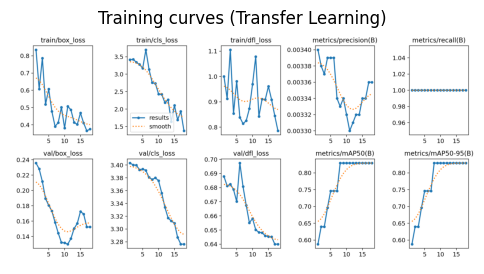

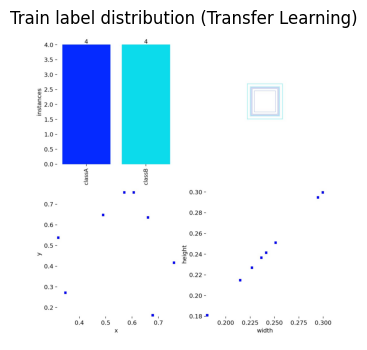

[Scratch] run: runs/object_detection/from_scratch_clean9


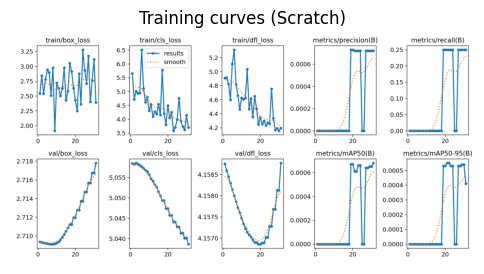

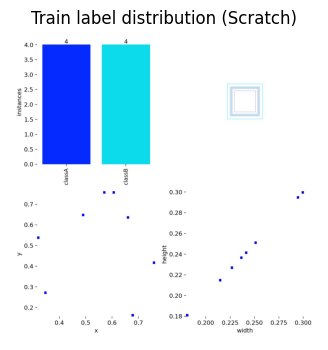

In [115]:
from pathlib import Path
import matplotlib.pyplot as plt
import os

# Latest run dirs (adjust if you want a specific run)
runs_root = Path("runs/object_detection")
last_tl = max((runs_root / "transfer_learning_clean").parent.glob("transfer_learning_clean*"), key=os.path.getmtime)
last_scratch = max((runs_root / "from_scratch_clean").parent.glob("from_scratch_clean*"), key=os.path.getmtime)

def show_img(path, title=None):
    if Path(path).exists():
        img = plt.imread(path)
        plt.figure(figsize=(6,4)); plt.imshow(img); plt.axis("off");
        if title: plt.title(title);
        plt.show()
    else:
        print(f"[INFO] Missing: {path}")

print("[TL] run:", last_tl)
show_img(last_tl / "results.png", "Training curves (Transfer Learning)")
show_img(last_tl / "labels.jpg", "Train label distribution (Transfer Learning)")

print("[Scratch] run:", last_scratch)
show_img(last_scratch / "results.png", "Training curves (Scratch)")
show_img(last_scratch / "labels.jpg", "Train label distribution (Scratch)")